# Loan Prediction Model

This project is a **Machine Learning application** that predicts loan approval status based on applicant details such as income, credit history, loan amount, and other financial attributes.

---

## 📌 Project Overview
The goal of this project is to build a classification model that can assist financial institutions in making quick and reliable loan approval decisions.  

Key highlights:
- Data preprocessing (handling missing values, encoding categorical variables, scaling features).
- Train/Test split with stratification to maintain class balance.
- Model training using **Logistic Regression, Random Forest, and MultiOutputRegressor**.
- Model evaluation with **Accuracy, R² Score, and Mean Squared Error**.
- Final comparison of models for best performance.

---

## A. Data Cleaning Stage
Are there any missing values in the dataset? How should I handle them? (Drop, fill, or impute)

Are there duplicate rows or irrelevant columns that should be removed?

Are all data types correct (e.g., numbers stored as strings)?

Are categorical values consistent (e.g., “Male” vs “male” vs “M”)?

Do I need to scale or normalize numeric columns before modeling?

## B. Visualization & Exploration Stage
What is the distribution of each variable?

Which features are most strongly related to the target (Loan_Status)?

Are there any outliers that could affect the analysis?

How do numeric variables relate to each other (correlation heatmap)?

How do categorical variables affect loan approval rates (crosstab + bar chart)?

## C. Modeling Stage
Which features improve model accuracy the most?

Is my model overfitting or underfitting?

Have I tried multiple algorithms for comparison?

Did I check the confusion matrix to see which predictions fail most often?

If I remove one important feature, does the model s.





###   Example self-questions for Loan Prediction:

Do married applicants have a higher loan approval rate than unmarried ones?

Does higher ApplicantIncome always mean loan approval?

Is there a relationship between Property_Area and LoanAmount?

What happens to the model if I exclude Credit_History?






In [1]:
import pandas as pd
import numpy as np


In [2]:

# Load your data into a DataFrame
df = pd.read_csv('loan.csv')
df


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


Explores the data:

df.info() shows data types and missing values.

df.shape shows the number of rows and columns.

df.columns lists all column names.

df.describe() gives summary statistics.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [4]:
df.shape

(367, 12)

In [5]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [7]:

# check Missing values
df.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

Handles missing values:

Fills missing values in the 'LoanAmount' column with the mean of that column:-

In [8]:

# Fill missing values in 'LoanAmount' with the mean
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [9]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

In [10]:
# Visualizing missing values
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
df['Gender'].value_counts()


Gender
Male      286
Female     70
Name: count, dtype: int64

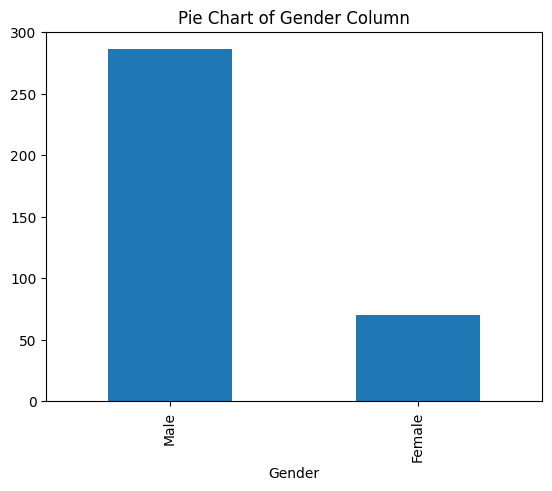

In [12]:

df["Gender"].value_counts().plot(kind='bar')   
plt.title("Pie Chart of Gender Column")
plt.ylabel("")
plt.show()

<Axes: xlabel='Married'>

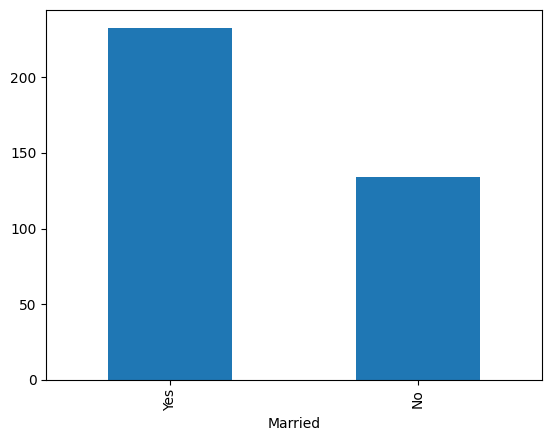

In [13]:
df['Married'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

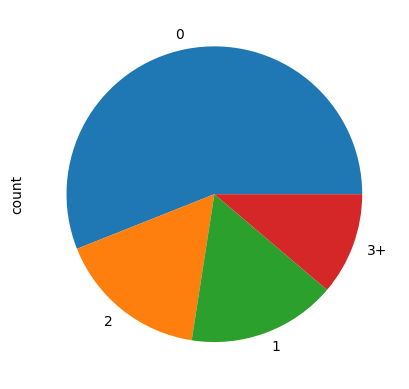

In [14]:
df['Dependents'].value_counts().plot(kind='pie')

<Axes: xlabel='Education'>

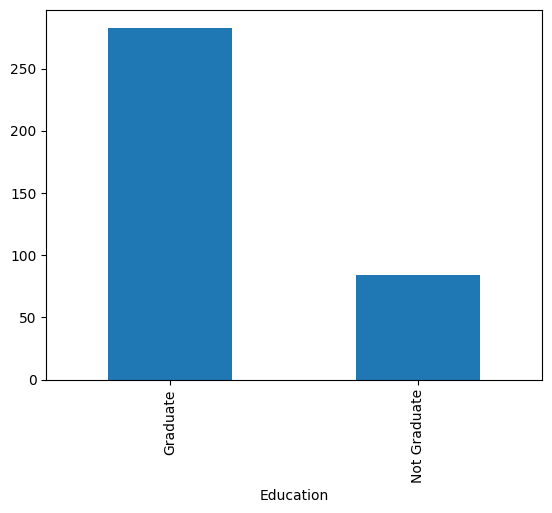

In [15]:
df.Education.value_counts().plot(kind='bar')

<Axes: xlabel='Self_Employed'>

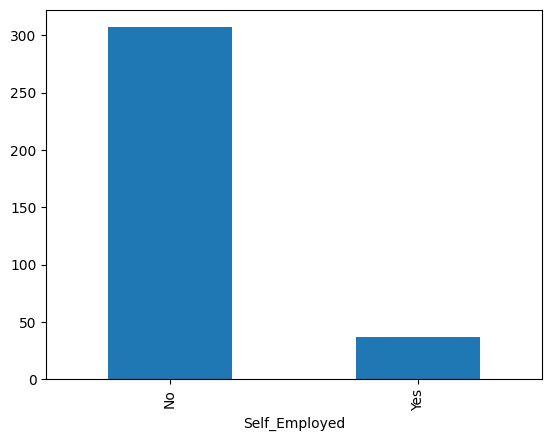

In [16]:
df.Self_Employed.value_counts().plot(kind='bar')

In [17]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

<Axes: ylabel='Density'>

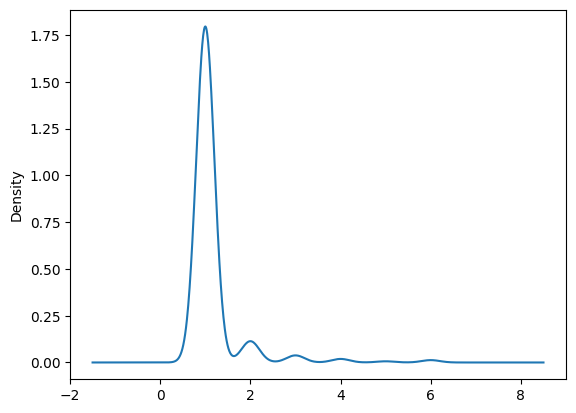

In [18]:
df.ApplicantIncome.value_counts().plot(kind='kde')


<Axes: ylabel='Frequency'>

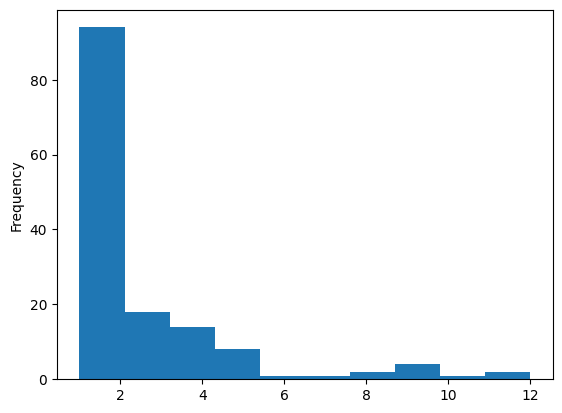

In [19]:
df.LoanAmount.value_counts().plot(kind='hist')


In [20]:
df.dtypes


Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

## Relationships:-     

# ## Two-column relationships
Categorical vs Categorical

Use pd.crosstab() + heatmap or grouped bar chart.


    Numerical vs Categorical

Use box plots or violin plots.


Numerical vs Numerical

Use scatter plots + correlation heatmap.


### Three or more columns
Hue in Seaborn: Adds a third column as color

FacetGrid in Seaborn: Creates subplots for categories.

                                      Pivot Tables + Heatmap:


## 1. Numeric vs Categorical


<Axes: xlabel='ApplicantIncome', ylabel='Property_Area'>

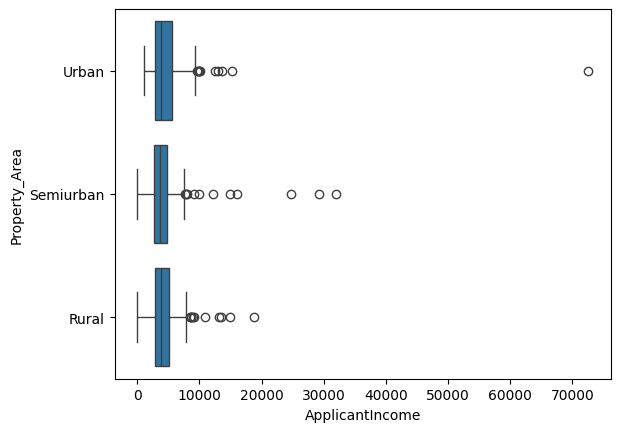

In [21]:
sns.boxplot(x='ApplicantIncome',y='Property_Area',data=df)

<Axes: xlabel='ApplicantIncome', ylabel='Self_Employed'>

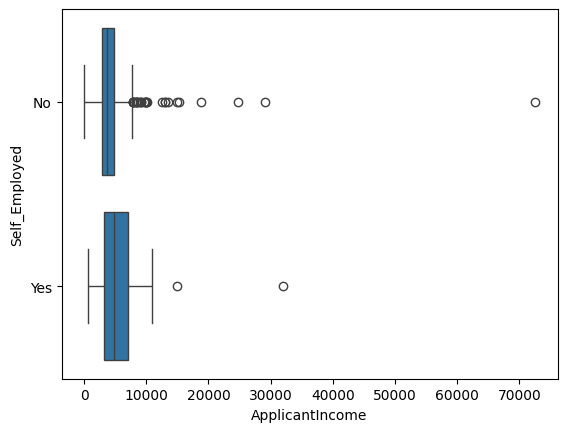

In [22]:
sns.boxplot(x='ApplicantIncome',y='Self_Employed',data=df)

<Axes: xlabel='LoanAmount', ylabel='Credit_History'>

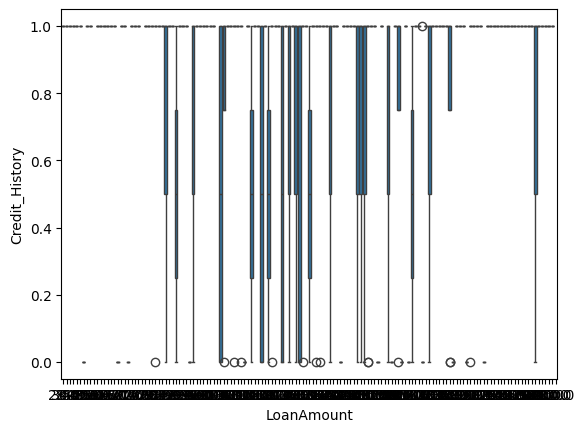

In [23]:
sns.boxplot(x='LoanAmount',y='Credit_History',data=df)

<Axes: xlabel='LoanAmount', ylabel='Education'>

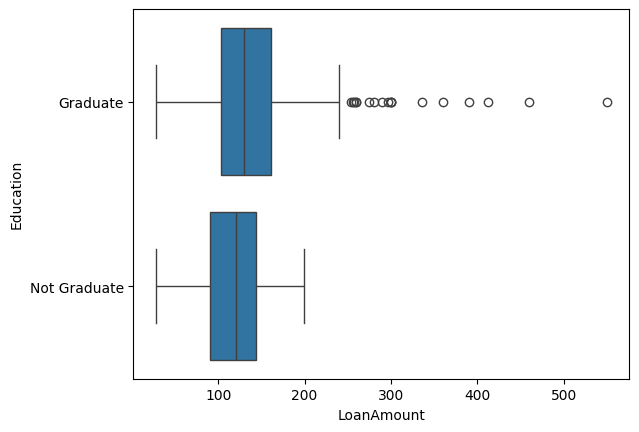

In [24]:
sns.boxplot(x='LoanAmount',y='Education',data=df)

## 2.Numeric vs Numeric

<Axes: xlabel='ApplicantIncome', ylabel='LoanAmount'>

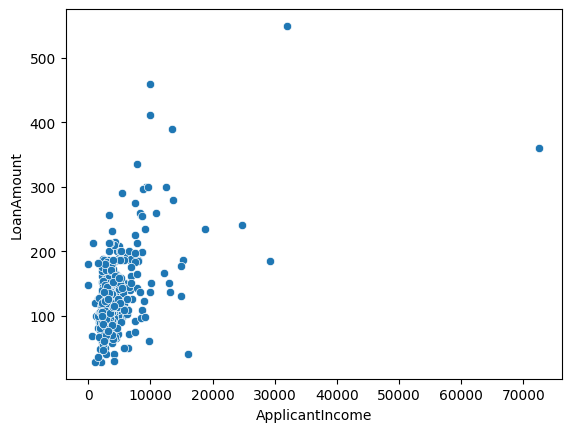

In [25]:
sns.scatterplot(x='ApplicantIncome',y='LoanAmount',data=df)

<Axes: xlabel='CoapplicantIncome', ylabel='LoanAmount'>

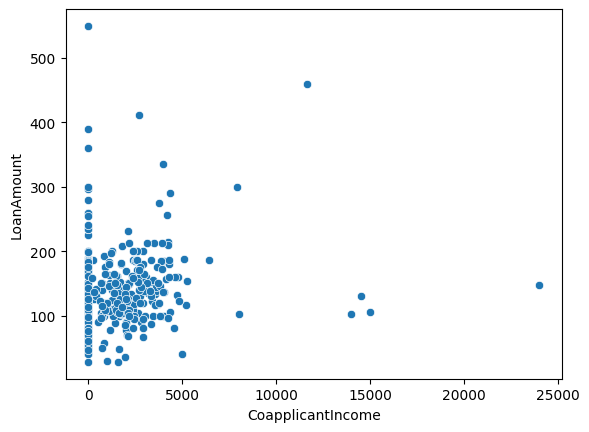

In [26]:
sns.scatterplot(x='CoapplicantIncome',y='LoanAmount',data=df)

<Axes: xlabel='Loan_Amount_Term', ylabel='LoanAmount'>

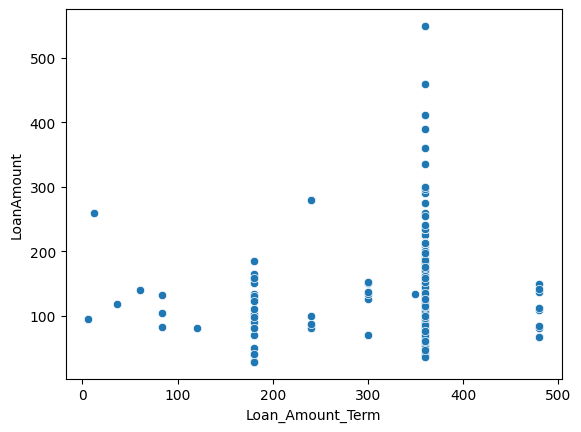

In [27]:
sns.scatterplot(x='Loan_Amount_Term',y='LoanAmount',data=df)

## 3. categorical vs Categorical

<Axes: xlabel='Married', ylabel='Gender'>

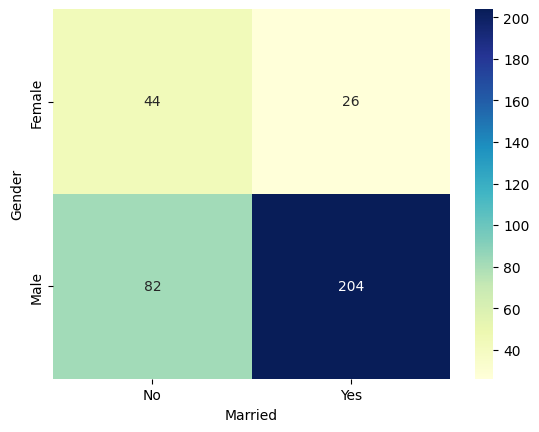

In [28]:
# Categorical vs Categorical
# Gender vs Married → Heatmap of counts


# Create a count table
count_table = pd.crosstab(df['Gender'], df['Married'])

# Plot heatmap
sns.heatmap(count_table, annot=True, fmt='d', cmap='YlGnBu')





<Axes: xlabel='Property_Area', ylabel='count'>

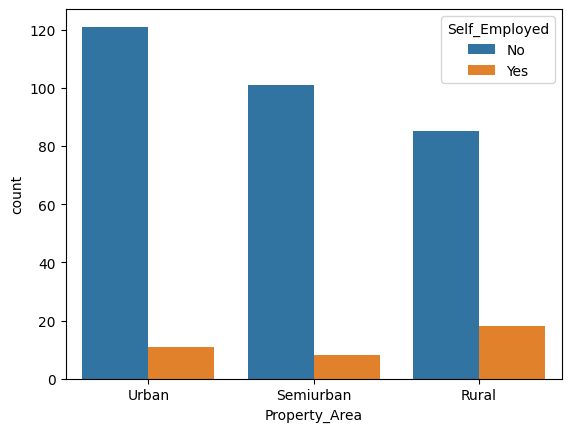

In [29]:
sns.countplot(x='Property_Area', hue='Self_Employed', data=df)


## Step : Visualize Numeric vs Categorical


What this shows:

Income distribution across education levels.

Loan amount distribution across property areas.

You can see if certain categories get higher loans or have higher income, which may influence loan approval.

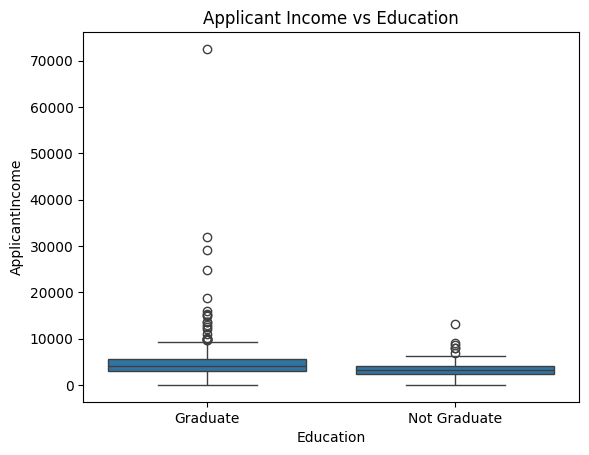

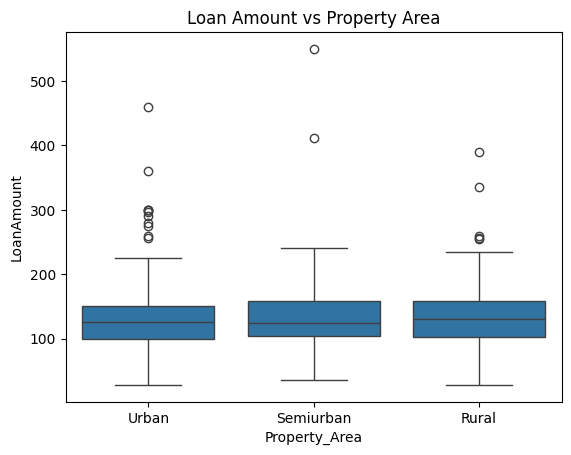

In [30]:
# Numeric vs Categorical

# Boxplot: ApplicantIncome vs Education
sns.boxplot(x='Education', y='ApplicantIncome', data=df)
plt.title('Applicant Income vs Education')
plt.show()

# Boxplot: LoanAmount vs Property_Area
sns.boxplot(x='Property_Area', y='LoanAmount', data=df)
plt.title('Loan Amount vs Property Area')
plt.show()


## step : Statistical Summary

You can also compute mean loan amounts grouped by categorical variables:



In [31]:
# Mean LoanAmount by Education
df.groupby('Education')['LoanAmount'].mean()

# Mean LoanAmount by Property_Area
df.groupby('Property_Area')['LoanAmount'].mean()

Property_Area
Rural        138.163357
Semiurban    134.079872
Urban        136.223323
Name: LoanAmount, dtype: float64

handling missing values and encoding categorical features—this is crucial before feeding data into any machine learning model.

## Step 1: Check Missing Values

In [32]:
# Check missing values
df.isnull().sum()


Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

Fill missing numeric values with mean or median:

Numeric Columns:


In [33]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['ApplicantIncome'].fillna(df['ApplicantIncome'].median(), inplace=True)


C:\Users\welcome\AppData\Local\Temp\ipykernel_16432\2174675328.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
C:\Users\welcome\AppData\Local\Temp\ipykernel_16432\2174675328.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

Categorical Columns

Fill missing categorical values with mode (most frequent value):

In [34]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)


C:\Users\welcome\AppData\Local\Temp\ipykernel_16432\146558906.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\welcome\AppData\Local\Temp\ipykernel_16432\146558906.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

## Step2:Encode Categorical Features

Machine learning models need numerical input, so we convert categorical features:

3a. Label Encoding for binary categories

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Married'] = le.fit_transform(df['Married'])
df['Education'] = le.fit_transform(df['Education'])
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])
# df['Loan_Status'] = le.fit_transform(df['Loan_Status'])  # Target variable (removed, column not present)


One-Hot Encoding for multi-class categories:

In [36]:
df = pd.get_dummies(df, columns=['Property_Area', 'Dependents'], drop_first=True)


drop_first=True avoids dummy variable trap.


After this step

Your dataset will have no missing values.

All categorical features will be converted into numerical form.

You’re ready for feature scaling (if needed) and model building.

Now that your dataset is cleaned and encoded, let’s move to the next step:

## 🔹 Splitting Data and Building Your First Model
Step 1: Split Features & Target

 If your dataset doesn’t have Loan_Status (just for practice)

👉 Create a balanced target:

In [37]:
import numpy as np

np.random.seed(42)
df['Loan_Status'] = np.random.choice([0, 1], size=len(df))


# Double-check before splitting

# Run these checks:
print(df['Loan_Status'].value_counts())# Should show both 0 and 1



Loan_Status
0    184
1    183
Name: count, dtype: int64


Loan_Status should show counts for both 0 and 1.

Shapes should match (same number of rows).

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop(['Loan_ID', 'Loan_Status'], axis=1, errors='ignore')
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.isnull().sum().sum())  # should be 0
print(y_train.isnull().sum())        # should be 0

0
0


In [39]:
# If original dataset has Loan_Status, keep it. 
# If missing, create random 0/1 for practice:
if 'Loan_Status' not in df.columns:
    np.random.seed(42)
    df['Loan_Status'] = np.random.choice([0, 1], size=len(df))




In [40]:
# Add a dummy Loan_Status column just for practice
# df['Loan_Status'] = 1
  # or random values 0/1
#Then when splitting:

X = df.drop(['Loan_ID', 'Loan_Status'], axis=1, errors='ignore')
y = df['Loan_Status']

print(X.columns)
print(X.head())

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome',
       'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History',
       'Property_Area_Semiurban', 'Property_Area_Urban', 'Dependents_1',
       'Dependents_2', 'Dependents_3+'],
      dtype='object')
   Gender  Married  Education  Self_Employed  ApplicantIncome  \
0       1        1          0              0             5720   
1       1        1          0              0             3076   
2       1        1          0              0             5000   
3       1        1          0              0             2340   
4       1        0          1              0             3276   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0       110.0             360.0             1.0   
1               1500       126.0             360.0             1.0   
2               1800       208.0             360.0             1.0   
3               2546       100.0    

In [41]:
y = df['Loan_Status']

Step 2: Train-Test Split

We split the dataset into training (for model learning) and testing (for evaluation):

In [42]:
from sklearn.model_selection import train_test_split

# Check if 'Loan_Status' exists in the DataFrame
print(df.columns)  # Check column names

# Set y as the target
y = df['Loan_Status']
# Drop 'Loan_ID' and 'Loan_Status' from features
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1,errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Training data")
print(X_train)

print("Test data")
print(X_test)

print("Training labels")
print(y_train)

print("Test labels")
print(y_test)

Index(['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Loan_Status'],
      dtype='object')
Training data
     Gender  Married  Education  Self_Employed  ApplicantIncome  \
152       1        0          0              0             5000   
304       1        1          0              0             2600   
339       0        0          0              0             4333   
77        1        0          0              1             6356   
288       1        0          0              0             4983   
..      ...      ...        ...            ...              ...   
136       1        1          0              0             4500   
65        1        1          0              0             2917   
133       0        0          0              0           

stratify=y → ensures target distribution is balanced in train/test.

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


c:\Users\welcome\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

## Step 4: Make Predictions

In [44]:

y_pred = model.predict(X_test)


## Step 5: Evaluate Model

In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5

Confusion Matrix:
 [[14 23]
 [14 23]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.38      0.43        37
           1       0.50      0.62      0.55        37

    accuracy                           0.50        74
   macro avg       0.50      0.50      0.49        74
weighted avg       0.50      0.50      0.49        74



✅ This will give you accuracy, precision, recall, and F1-score.

## Let’s compare multiple models side by side for your Loan Prediction project.

We’ll test Logistic Regression, Decision Tree, Random Forest, and XGBoost.

### Step 1: Import Model:


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier   # install xgboost if not already
from sklearn.metrics import accuracy_score


### Step 2: Train and Evaluate Models

We’ll loop through different models to compare performance:

In [47]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


c:\Users\welcome\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.5000
Decision Tree Accuracy: 0.4865
Random Forest Accuracy: 0.4730
XGBoost Accuracy: 0.4730


c:\Users\welcome\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:19:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Step 3: Compare Results

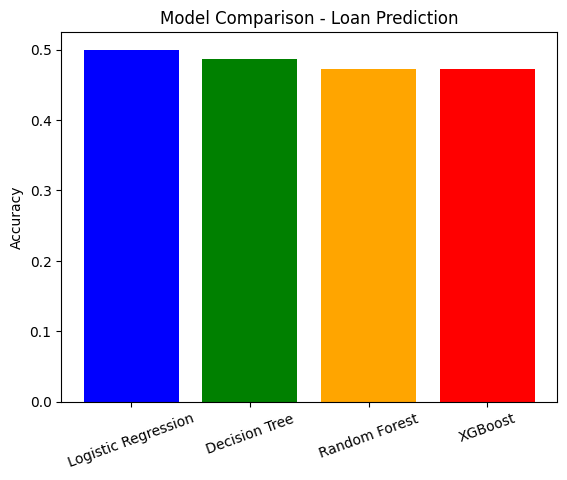

In [48]:
import matplotlib.pyplot as plt

# Plot accuracy comparison
plt.bar(results.keys(), results.values(), color=['blue','green','orange','red'])
plt.ylabel("Accuracy")
plt.title("Model Comparison - Loan Prediction")
plt.xticks(rotation=20)
plt.show()


## What this does:

Trains 4 models.

Prints their accuracy.

Shows a bar chart comparison.

# We have already:

- Cleaned and encoded your data
- Split it into training and test sets
- Trained and compared multiple models
- Evaluated their accuracy

**Next steps we can try:**

1. **Tune Hyperparameters:** Use GridSearchCV or RandomizedSearchCV to improve model performance.
2. **Feature Importance:** Check which features are most important for predictions (especially with tree-based models).
3. **Cross-Validation:** Use cross-validation to get a more robust estimate of model performance.
4. **Analyze Errors:** Look at misclassified cases to understand where your model struggles.
5. **Try More Models:** Experiment with other algorithms (e.g., SVM, KNN).
6. **Export Model:** Save your best model for future use (with `joblib` or `pickle`).



## 1️⃣ Hyperparameter Tuning: GridSearchCV & RandomizedSearchCV
GridSearchCV Example (RandomForest)

#### How this gridsearchcv wroks ?
Here's a fun and concise problem-solution explanation.

The Problem 🤔: Too Many Knobs!
Imagine you have a super-robot 🤖, but it has dozens of settings (like speed, power, and intelligence). You want to find the perfect combination to make it the ultimate champion, but trying every single combo by hand would take forever and be incredibly boring.

The Solution 🏆: The Master Coach!
Instead of guessing, you hire a Master Coach called GridSearchCV.

You give the coach a list of all the settings you want to try out.

The coach runs your robot through a tournament, making it compete with every single combination of those settings.

After the tournament, the coach simply walks up to you and says, "Here are the absolute best settings and the high score it achieved."

In short, GridSearchCV is your personal coach that automatically finds the ultimate, winning settings for your AI robot, saving you all the guesswork!



In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Grid Search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best params and score
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Accuracy: 0.5431326709526593


RandomizedSearchCV Example

In [50]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Parameter distribution
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10)
}

rand_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                                 n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
rand_search.fit(X_train, y_train)

print("Best Parameters:", rand_search.best_params_)
print("Best Accuracy:", rand_search.best_score_)


Best Parameters: {'max_depth': 12, 'min_samples_split': 9, 'n_estimators': 64}
Best Accuracy: 0.5020455873758036


In [51]:
from sklearn.model_selection import RandomizedSearchCV # This is our super smart helper 🤖 that will test different settings.
from scipy.stats import randint # This is like a special die 🎲 that helps us pick a random number.

# This is a list of all the settings we can change on our smart friend (the model).
# Think of it as a list of rules for our guessing game.
param_dist = {
    'n_estimators': randint(50, 200), # How many small teams will play the game? We'll try a random number between 50 and 200.
    'min_samples_split': randint(2, 10), # How many people are needed to form a new group? We'll try a number between 2 and 10.
    'max_depth': randint(3, 20), # How many questions can each team ask? We'll try a number between 3 and 20.
}
# We ask our super smart helper to find the best rules!
rand_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                                n_iter=10, # It will only try 10 different sets of rules.
                                cv=5, # It will play the game 5 times with each set of rules to make sure the results aren't just lucky!
                                scoring='accuracy', # This is how we keep score. We want to find the rules that give us the most "correct guesses".
                                random_state=42, # This makes sure that every time we play, the same random rules are chosen, so it's a fair test.
                                n_jobs=-1) # It's like having all your friends help you play so the game goes super fast! 💨
rand_search.fit(X_train, y_train) # Here, the helper actually starts playing the game and learning from the data.

# After the games are finished, we ask the helper to tell us the results.
print("Best Parameters:", rand_search.best_params_) # It tells us the best rules it found for our game.
print("Best Accuracy:", rand_search.best_score_) # It tells us the highest score it got with those best rules! 🏆



Best Parameters: {'max_depth': 12, 'min_samples_split': 9, 'n_estimators': 64}
Best Accuracy: 0.5020455873758036


# 2️⃣ Feature Importance (Tree-based Models)

This code is a tool for a "guessing game" that helps us find which clues are the most important. 🔎

model.fit(...): The code first gives the model all the clues and answers, so it can practice guessing.

importances = ...: The model then looks back at its guesses and figures out which clues were the most helpful. It gives each clue a score based on how important it was.

plt.plot(...): Finally, the code makes a bar chart to show the importance of each clue. The taller the bar, the more important the clue was for the model's guessing!

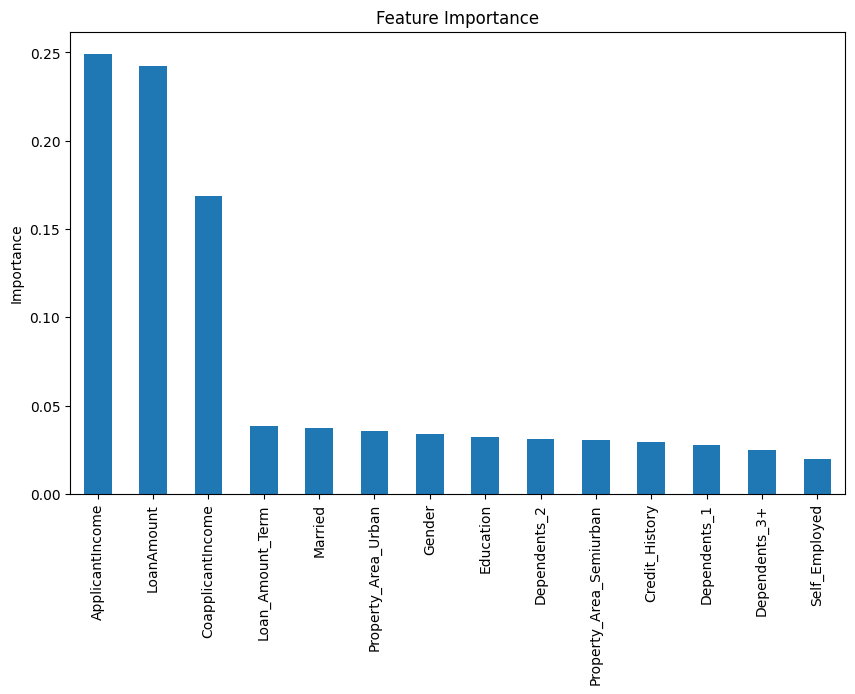

In [52]:

import matplotlib.pyplot as plt
import pandas as pd

# Use RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Feature importances
importances = model.feature_importances_
features = X_train.columns
feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
feat_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

# 3️⃣ Cross-Validation
This code is like giving our "guessing game" model a final test to make sure it's reliable.

How it works
cross_val_score(...): This part acts like a teacher who splits the test questions into 5 different groups. The model then takes each of the 5 tests.

scores = ...: The code saves the score from each of the 5 tests.

print("Mean Accuracy:", scores.mean()): Finally, it calculates the average score across all 5 tests. This average score is a much more trustworthy measure of how good the model is at guessing, because it wasn't just a one-time lucky guess!

In [53]:

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation scores: [0.41891892 0.37837838 0.50684932 0.57534247 0.54794521]
Mean Accuracy: 0.4854868567197334


# 4️⃣ Analyze Errors
This code helps us review the mistakes our "guessing game" model made.

confusion_matrix(...): This creates a simple table that shows how many guesses were right and how many were wrong. For example, it tells us how many times the model correctly guessed something was 'A' and how many times it incorrectly guessed 'A' when it was really 'B'.

classification_report(...): This is a report card for each type of guess. It gives us scores that tell us how good the model was at getting a specific type of guess right and how good it was at finding all of a certain thing.

misclassified = ...: This part shows us the exact information for every single mistake the model made, so we can see what types of problems it's having.

In [54]:

from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Misclassified rows
misclassified = X_test[y_test != y_pred]
print("Misclassified samples:\n", misclassified)

Confusion Matrix:
 [[16 21]
 [18 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.43      0.45        37
           1       0.47      0.51      0.49        37

    accuracy                           0.47        74
   macro avg       0.47      0.47      0.47        74
weighted avg       0.47      0.47      0.47        74

Misclassified samples:
      Gender  Married  Education  Self_Employed  ApplicantIncome  \
195       1        0          0              1             5833   
41        0        0          0              0             3644   
300       1        1          0              1             7500   
115       1        0          0              0             4243   
293       0        1          0              0             2241   
341       1        0          0              1             3972   
306       1        1          0              1             7500   
5         1        1          1              1    

# 5️⃣ Try More Models
This code is a competition between different "guessing machines" to see which one is the best.

How It Works
models = { ... }: This creates a list of three different types of guessing machines: Random Forest, SVM, and KNN.

for name, m in models.items():: The code takes each machine and gives it a practice test.

score = m.score(...): After practicing, it gives each machine a real test and records their score.

print(...): Finally, it prints the score for each machine, so you can easily see which one won the competition and is the best at guessing!

In [55]:

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

for name, m in models.items():
    m.fit(X_train, y_train)
    score = m.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.4f}")


Random Forest Accuracy: 0.4730
SVM Accuracy: 0.5270
KNN Accuracy: 0.4595


# 6️⃣ Export Model
This code shows you how to save your trained "guessing machine" so you can use it again later without having to train it from scratch. It's like putting your favorite toy in a box so it's safe and ready to play with anytime. 🎁

What It Does
joblib.dump(model, 'loan_prediction_model.pkl'): This is the saving step. It takes your model (the guessing machine you've already trained) and saves it as a special file on your computer. The file name is loan_prediction_model.pkl. The .pkl at the end just means it's a special file for saving models.

loaded_model = joblib.load('loan_prediction_model.pkl'): This is the loading step. It's like opening the box to take out your toy. It opens the file you just saved and brings the guessing machine back into your program.

y_pred_loaded = loaded_model.predict(X_test): Now you can use the loaded machine to start making new guesses, just as you would with the original one.

This is super useful because you don't have to wait for the machine to "learn" all over again every time you want to use it

In [56]:

import joblib

# Save model
joblib.dump(model, 'loan_prediction_model.pkl')

# Load model
loaded_model = joblib.load('loan_prediction_model.pkl')
# Predict
y_pred_loaded = loaded_model.predict(X_test)

In [57]:
import joblib

# After preprocessing and before training
train_columns = X_train.columns.tolist()
joblib.dump(train_columns, "train_columns.pkl")


['train_columns.pkl']

In [58]:
import joblib

# -----------------------------
# Load the trained model & columns
# -----------------------------
model = joblib.load("loan_prediction_model.pkl")       # your trained pipeline
train_columns = joblib.load("train_columns.pkl")       # columns used during training
